In [13]:
import tskit
import pandas as pd
import tstrait
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot_2samples

In [2]:
def obtain_mutation_df(ts, selection_scaling):
    """Obtain mutation dataframe.

    Obtain mutation dataframe from a tree sequence that is simulated in slim
    We will multiply the final selection coefficient by -2*selection_scaling, due to
    how we are modeling selection coefficient in SLiM simulation.
    """
    mutation_list = []
    for i in range(ts.num_mutations):
        mutation = ts.mutation(i)

        mutation_list.append(
            {
                "site_id": ts.site(mutation.site).id,
                "site_position": ts.site(mutation.site).position,
                "selection_coeff": mutation.metadata["mutation_list"][0][
                    "selection_coeff"
                ],
                "causal_allele": mutation.derived_state,
                "trait_id": 0,
            }
        )

    mutation_df = pd.DataFrame(mutation_list)
    mutation_df["selection_coeff"] = (
        mutation_df["selection_coeff"] * selection_scaling * (-2)
    )

    return mutation_df

In [3]:
def sim_tstrait_pleiotropy(ts, n, selection_scaling=1e10, w2=1, rep=100, seed=None):
    """Simulate pleiotropic effects.

    ts is the input tree sequence, n is the degree of pleiotropic effects,
    selection_scaling is the scaling parameter used in SLiM simulation,
    w2 is the selection parameter, and seed is the seed used to simulate
    effect size.
    """
    rng = np.random.default_rng(seed=seed)
    mutation_df = obtain_mutation_df(ts, selection_scaling)
    mutation_df["effect_size"] = mutation_df.apply(
        lambda row: rng.normal(loc=0, scale=np.sqrt(row["selection_coeff"] * w2 / n)), axis=1
    )

    genetic_df = tstrait.genetic_value(ts, mutation_df)
    genetic_value = genetic_df["genetic_value"].to_numpy()

    genetic_value -= np.mean(genetic_value)

    return genetic_value

In [4]:
def sim_tstrait_n1(ts, selection_scaling=1e10, w2=1, seed=None):
    """Simulate effects when there is no pleiotropic effects.

    ts is the input tree sequence, selection_scaling is the scaling
    parameter used in SLiM simulation, w2 is the selection parameter,
    and seed is the seed used to simulate effect size.
    """
    rng = np.random.default_rng(seed=seed)
    mutation_df = obtain_mutation_df(ts, selection_scaling)
    mutation_df["effect_size"] = mutation_df.apply(
        lambda row: rng.choice([-1, 1])* np.sqrt(row["selection_coeff"] * w2 ), axis=1
    )

    genetic_df = tstrait.genetic_value(ts, mutation_df)
    genetic_value = genetic_df["genetic_value"].to_numpy()

    genetic_value -= np.mean(genetic_value)
    
    return genetic_value

In [5]:
# The tree sequences below are generated by using underdominant-selection.slim

In [6]:
ts = tskit.load("underdominance_popsize_1000_seed_1.tree")
n_1_genetic_value = sim_tstrait_n1(ts, seed=10)

In [7]:
ts = tskit.load("underdominance_popsize_1000_seed_2.tree")
n_3_genetic_value = sim_tstrait_pleiotropy(ts, n=3, seed=20)

In [8]:
ts = tskit.load("underdominance_popsize_1000_seed_3.tree")
n_10_genetic_value = sim_tstrait_pleiotropy(ts, n=10, seed=30)

In [9]:
ts = tskit.load("underdominance_popsize_1000_seed_4.tree")
n_100_genetic_value = sim_tstrait_pleiotropy(ts, n=100, seed=40)

In [10]:
# These files are generated by using stabilizing-selection.slim (for pleiotropic)
# and stabilizing-selection-1d.slim (for non-pleiotropic)
n1_stabilizing = np.loadtxt("stabilizing_phenotype_n_1_N_1000_seed_1000.txt")
n3_stabilizing = np.loadtxt("stabilizing_phenotype_n3_N_1000_seed_110.txt")
n10_stabilizing = np.loadtxt("stabilizing_phenotype_n10_N_1000_seed_120.txt")
n100_stabilizing = np.loadtxt("stabilizing_phenotype_n100_N_1000_seed_130.txt")

In [11]:
n1_stabilizing_plot = n1_stabilizing - np.mean(n1_stabilizing)
n3_stabilizing_plot = n3_stabilizing - np.mean(n3_stabilizing)
n10_stabilizing_plot = n10_stabilizing - np.mean(n10_stabilizing)
n100_stabilizing_plot = n100_stabilizing - np.mean(n100_stabilizing)

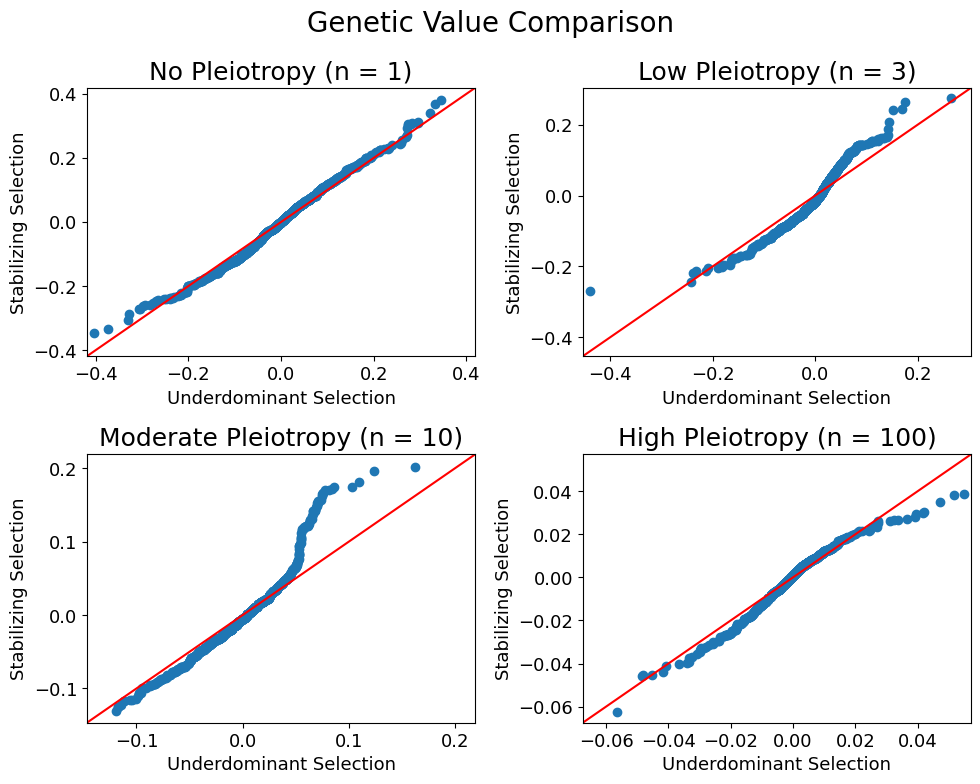

In [20]:
plt.rcParams.update({'font.size': 13})
fig, axes = plt.subplots(2, 2, tight_layout=True, figsize=(10, 8))
qqplot_2samples(n_1_genetic_value, n1_stabilizing_plot, xlabel="Underdominant Selection", ylabel="Stabilizing Selection", line="45", ax=axes[0,0])
qqplot_2samples(n_3_genetic_value, n3_stabilizing_plot, xlabel="Underdominant Selection", ylabel="Stabilizing Selection", line="45", ax=axes[0,1])
qqplot_2samples(n_10_genetic_value, n10_stabilizing_plot, xlabel="Underdominant Selection", ylabel="Stabilizing Selection", line="45", ax=axes[1,0])
qqplot_2samples(n_100_genetic_value, n100_stabilizing_plot, xlabel="Underdominant Selection", ylabel="Stabilizing Selection", line="45", ax=axes[1,1])

axes[0,0].set_title("No Pleiotropy (n = 1)", size=18)
axes[0,1].set_title("Low Pleiotropy (n = 3)", size=18)
axes[1,0].set_title("Moderate Pleiotropy (n = 10)", size=18)
axes[1,1].set_title("High Pleiotropy (n = 100)", size=18)
fig.suptitle("Genetic Value Comparison", size=20)
plt.savefig("simulation-comparison-genetic-value.pdf")
plt.show()